# Ridewise -- Feature Engineering 
- Transform clean riders and the trips data that can help have a  better churn prediction
-Engineer 20 + features 
- (1) RFM framework = (2) Behavioral + (3) Temporal Signals

# Step 1 - Setup

In [25]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, warnings



warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

# Define file paths
DATA_PREPROCESSED = os.path.join("..", "data", "processed")

# load the datasets
riders = pd.read_csv(os.path.join(DATA_PREPROCESSED, "riders_clean.csv"))
drivers = pd.read_csv(os.path.join(DATA_PREPROCESSED, "drivers_clean.csv"))
trips = pd.read_csv(os.path.join(DATA_PREPROCESSED, "trips_clean.csv"), parse_dates=["pickup_time", "dropoff_time"])
sessions = pd.read_csv(os.path.join(DATA_PREPROCESSED, "sessions_clean.csv"))

# Reference data
# In real ML deployment settings, reference_date means NOW
# we calculate "days since last trip"
reference_date = trips["pickup_time"].max()  

### Step 1A Engineering some Rider Features
 - 1 Eligible Riders (AKA Active) : check for riders who had atleast 1 trip
 - 2  check for riders who had trips in the last 60days 

-Note Reason: This can be used for promotional campaigns targetting active riders



In [26]:
# Eligibility Riders
riders["signup_date"] = pd.to_datetime(riders["signup_date"])
riders_with_trips = set(trips["user_id"])

# check for the account age in days (How old is this rider's account)
riders["account_age_days"] = (reference_date - riders["signup_date"]).dt.days

# Eligible Riders (1-  Account >=60 days and 2- atleast 1 trip )
eligible = riders[riders["user_id"].isin(riders_with_trips) & (riders["account_age_days"] >= 60)][["user_id","churned"]].copy()

#### Step 1 B - Engineering RFM Features
RFM ----- Recency, Frequency, Monetary (Revenue Metrics)

In [27]:
# Recency : How long since the last trip
last_trip= (
    trips.groupby("user_id")["pickup_time"].max()
    .reset_index(name="last_trip"))

last_session = (
    sessions.groupby("rider_id")["session_time"].max()
    .reset_index().rename(columns={ "session_time": "last_session", "rider_id": "user_id" }))


# Recency : Combination of group 1 and group 2 
recency =(eligible[["user_id"]].merge(last_trip, on="user_id", how="left").merge(last_session, on="user_id", how= "left"))

recency["last_session"] = pd.to_datetime(recency["last_session"])

# calculate the recency features
recency["days_since_last_trip"]= (reference_date - recency["last_trip"]).dt.days
recency["days_since_last_session"] = (reference_date - recency["last_session"]).dt.days

# Final Recency Features
recency = recency[["user_id","days_since_last_trip","days_since_last_session"]]

recency.head()

,user_id,days_since_last_trip,days_since_last_session
0,R00000,25,0.0
1,R00001,5,0.0
2,R00002,14,0.0
3,R00004,12,0.0
4,R00005,2,0.0


In [28]:
frequency = eligible[["user_id"]].copy()

for days in (7,30,60,90):

    cutoff = reference_date - pd.Timedelta(days=days)

    counts = (
        trips[trips["pickup_time"] >= cutoff]
        .groupby("user_id")
        .size()
        .reset_index(name=f"trips_last_{days}_days")
    )

    frequency = frequency.merge(counts, on="user_id", how="left")


# after loop
freq_cols = [f"trips_last_{d}_days" for d in [7,30,60,90]]

frequency[freq_cols] = frequency[freq_cols].fillna(0).astype(int)

frequency.head()

,user_id,trips_last_7_days,trips_last_30_days,trips_last_60_days,trips_last_90_days
0,R00000,0,1,1,3
1,R00001,1,2,3,3
2,R00002,0,1,4,5
3,R00004,0,2,2,5
4,R00005,1,2,2,4


In [29]:
# Step 1
# Frequency : How many trips in the last 30 or 60 days for example or rolling window ?
# creating a variable that only contain the ID of the riders that are eligible
frequency = eligible[["user_id"]].copy()

# Define the rolling window (7,30,50, 60)
# we want to calculate the number of trips in 7,30,60,90 days

# Step 2
for days in (7,30,60,90):
    # calculate the cutooff date for the rolling window
    # reference_date : Maximum pickup_time in the trips dataset
    cutoff = reference_date - pd.Timedelta(days=days)

    # counts the number of trips in the rolling window
    counts = (
        #filter show me only the trips that happened the cutoff date
        trips[trips["pickup_time"] >= cutoff]
        .groupby("user_id").size().reset_index(name=f"trips_last_{days}_days"))
    
    # merge the counts with the frequency dataframe
    frequency = frequency.merge(counts, on="user_id", how="left")


    
freq_cols = [f"trips_last_{d}_days" for d in [7,30,60,90]]

frequency[freq_cols] = frequency[freq_cols].fillna(0).astype(int)
frequency.head()

,user_id,trips_last_7_days,trips_last_30_days,trips_last_60_days,trips_last_90_days
0,R00000,0,1,1,3
1,R00001,1,2,3,3
2,R00002,0,1,4,5
3,R00004,0,2,2,5
4,R00005,1,2,2,4


In [30]:
# Monetary REvenue Metrics (Lifetime Revenue)

# Monetary Features
#  (Monetary Total)---High Value Customers (Higher Retention Priority-- perls, discounts)
# Monetary Average (Average fare per year )-- Budget User or Premium User
# Monetary Last 30days (Did they spend money recently)
# People with high trips but spends low
# People with low trips but spends high ---Occcasional Premium 

monetary = (
    trips.groupby("user_id")
    .agg(
        monetary_total=("total_revenue", "sum"),
        monetary_avg=("total_revenue", "mean"),
        trips_lifetime=("trip_id", "count"),
    )
    .round(2)
    .reset_index()
)


# Monetary in the last 30 days 
cutoff_30 = reference_date - pd.Timedelta(days=30)
monetary_30 = (
    trips[trips["pickup_time"] >= cutoff_30]
    .groupby("user_id")["total_revenue"]
    .sum()
    .reset_index(name="monetary_last_30d")
)


monetary = monetary.merge(monetary_30, on="user_id", how ="left")
monetary["monetary_last_30d"] = monetary["monetary_last_30d"].fillna(0)
monetary.head()

,user_id,monetary_total,monetary_avg,trips_lifetime,monetary_last_30d
0,R00000,414.13,16.57,25,16.310
1,R00001,195.69,13.98,14,26.830
2,R00002,482.94,20.12,24,14.900
3,R00003,146.15,16.24,9,0.000
4,R00004,391.15,24.45,16,45.718


## Step 2 RFM Score: Quantile Binning

- Group these riders based on how often they take trips (Grouping)

-Problem: Its hard to group them brcause they have continuous values 
- rider A took trip in the last 30days
- rider B took trip in the last 90 days 
-We need to put riders in a bucket or categories riders (Binning)
E.g 
-trips from 1-10days
-trips from 10-20days
-trips from 30-90days

In [31]:
# Step 2a- RFM Score:
# Tell us how valuable s customer is 
# E.g  Rider A---- days since the trips (5 days)---- trips in 30days (12 trips )----total money spent ($100)
# E.g  Rider B---- days since the trips (3 days)---- trips in 30days (32 trips )----total money spent ($200)


# Step 2b - Problem with RFM data
# the data has different scales
# e.g How do you compare 5days to 12 trips to $100

# Step 2c---Solution with RFM Score (put the data into a scale e.g 1-5scale)
# we convert each riders RFM  Metrics to 1-5 score where
# E.g 5 --- Best (most valuable for retention)
# E.g 1---- Worst (Highest church risk)

# Step 2d -- Quantile Binning---- BFM score 
# mean : divide the riders into 5 different groups (20% each) and  score (step 2c)

# Step 2e -- Recency Score -- Lower days = Better (5days vs 40days)
# Rank | Riders | Days since last trip | Group      |  Score (1-5)
# 1      Esther    5 days                 top 20%         5
# 2      Emmanuel  45 days                 40%            1
# 3      Samuel    10 days                 60%            4

# Esther rode 5days ago---She is engaged ----Score 5
# Emmanuel hasnt ridden in 45 days--- likely to churn--- Score 1


# Step 2f--- Frequency Score 
# formular ----- More trips = Better 
# Rank | Riders | Days since last trip | Group      |  Score (1-5)
# 1      Esther    12 days                top 20%        5 most frequent
# 2      Emmanuel  2 days                 40%            1 less frequent
# 3      Samuel    8 days                 60%            4 moderately frequent
# Esther took 12 trips/month ---- frequent user---- score 5 
# Emmanuel took 2 trips/month ---- inactive user---- score 1


# Step 2g --- Monetary Score 
# formular = more spending = better 
# Rank | Riders    | money spent| Group      |  Score (1-5)
# 1      Esther        $450        top 20%         5
# 2      Emmanuel      $50          40%            1
# 3      Samuel        $250         60%            3
# Esther spent $450 ---- High Lifetime Value Customer---- Score 5
# Emmanuel spent $50 ---- Low Lifetime Value Customer---- Score 1
# Samuel spent $250 ---- Moderate Lifetime Value Customer---- Score 3


# Step 2h----Final RFM score (RS +  FS  + MS)
# Riders|  Recency Score    | Frequency Score|  Monetary Score| Combined Score  
# Esther        5                   5               5               (5=5=5)/3 = 5.0 score
# Emmanuel      1                   1               1               (1=1=1)/3 = 1.0 score
# Samuel        4                   3               3               (4=3=3)/3 = 3.3 score

# Step 2i why does this matter to cburn prdiction
# churn rate  y RFM combine score

# score | Interpretation   |  churn rate
# 5.0   | excellent rider  ! 2%rarely churned 
# 4.0   | loyal rider      ! 5% churned rate
# 1.0   |  lost rider      ! 60% churned rate
# 3.0   | At risk          | 15% churned rate





In [32]:
# RFM Score (1-5 Quantile Bins)

# Merging R + F + M
rfm = (
    recency[["user_id", "days_since_last_trip"]]
    .merge(frequency[["user_id", "trips_last_30_days"]], on="user_id", how="left")
    .merge(monetary[["user_id", "monetary_total"]], on="user_id", how="left")
    .fillna({"trips_last_30_days": 0, "monetary_total": 0})
)

# Derive Recency Score 
rfm["recency_score"] = pd.qcut(
    rfm["days_since_last_trip"].rank(method="first"),
    q=5,
    labels=[5,4,3,2,1]
).astype(int)



# Derive Frequency Score
rfm["frequency_score"] = pd.qcut(
    rfm["trips_last_30_days"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

# Derive Monetary Score
rfm["monetary_score"] = pd.qcut(
    rfm["monetary_total"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

# Derive Combined RFM Score
rfm["rfm_score_combined"] = (rfm["recency_score"] + rfm["frequency_score"] + rfm["monetary_score"])
rfm["rfm_score_combined"] = rfm["rfm_score_combined"].round()


In [33]:
rfm.head()

,user_id,days_since_last_trip,trips_last_30_days,monetary_total,recency_score,frequency_score,monetary_score,rfm_score_combined
0,R00000,25,1,414.13,2,1,4,7
1,R00001,5,2,195.69,4,3,1,8
2,R00002,14,1,482.94,3,1,5,9
3,R00004,12,2,391.15,3,3,3,9
4,R00005,2,2,300.63,5,3,2,10


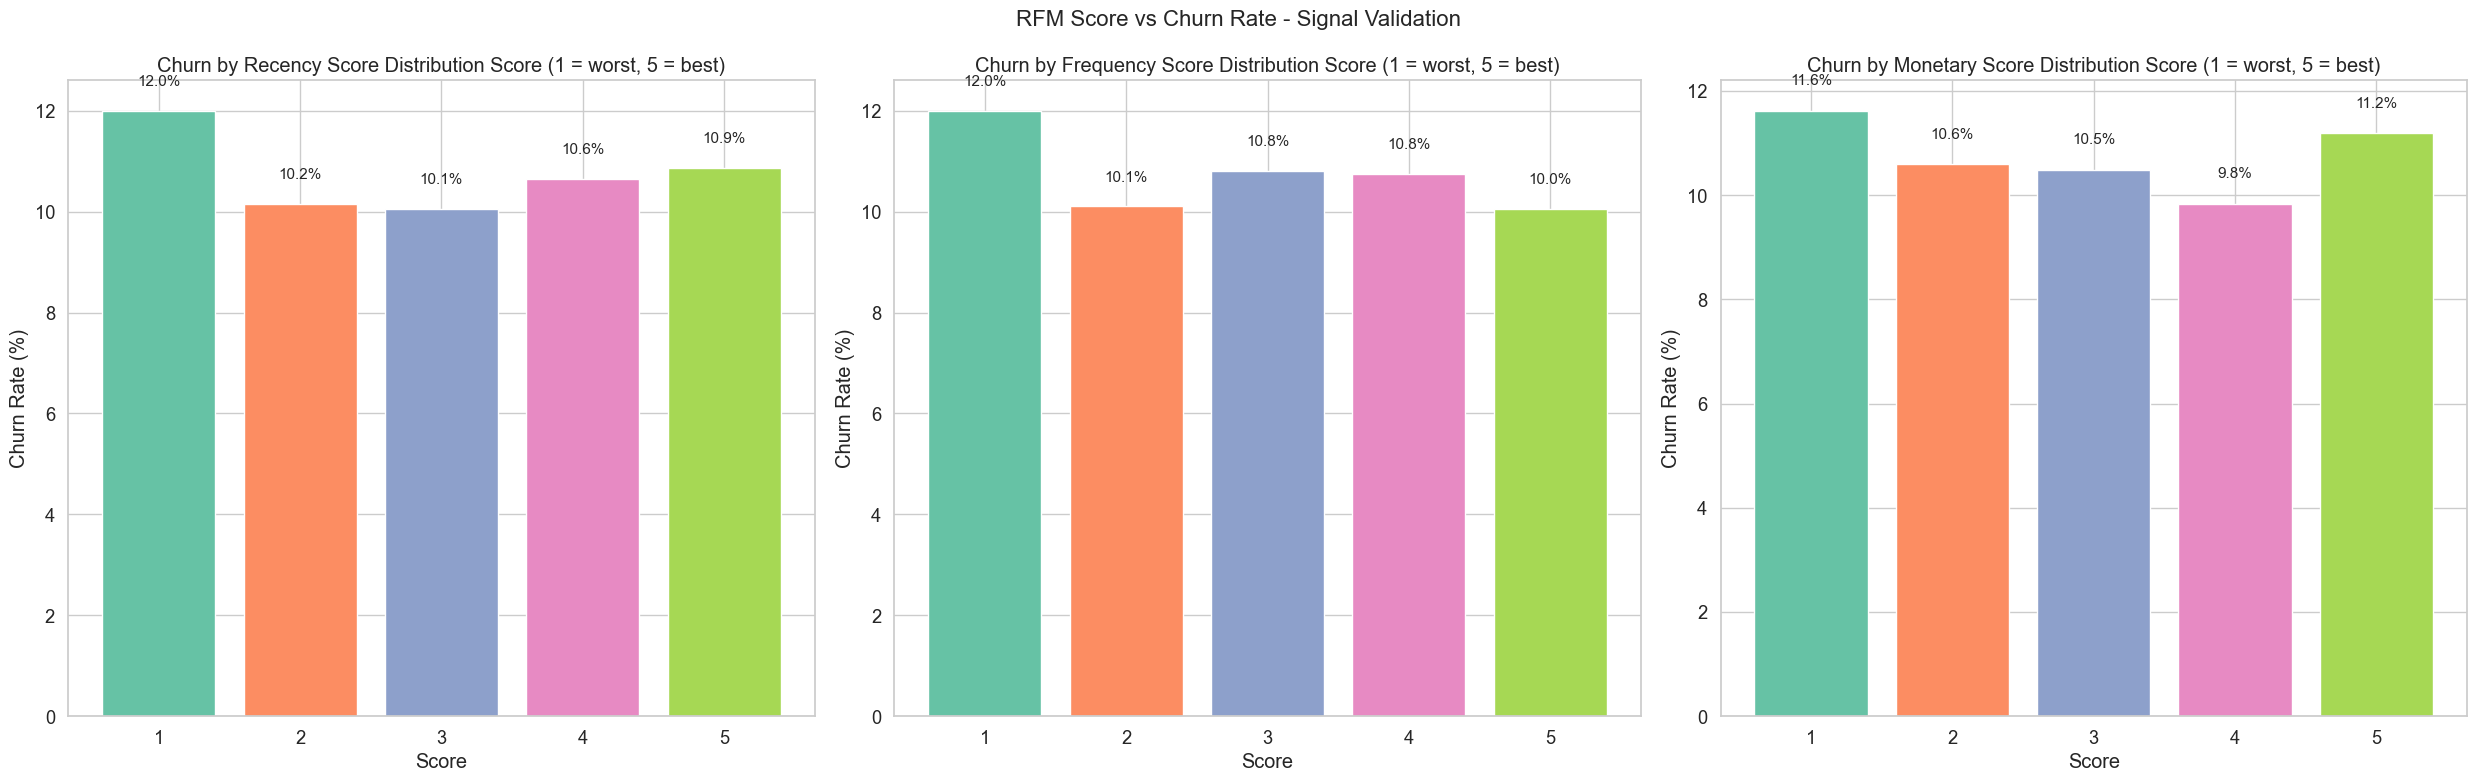

In [34]:
rfm_churn = rfm.merge(eligible, on="user_id", how="left")

fig, axes = plt.subplots(1, 3, figsize=(25, 8))

for ax, col, title in zip(
    axes,
    ["recency_score", "frequency_score", "monetary_score"],
    ["Recency Score Distribution", "Frequency Score Distribution", "Monetary Score Distribution"]
):

    data = (
        rfm_churn.groupby(col)["churned"]
        .mean()
        .mul(100)
        .reset_index()
    )

    ax.bar(
        data[col].astype(int),
        data["churned"],
        color=sns.color_palette("Set2"),
        edgecolor="white"
    )

    ax.set(
        title=f"Churn by {title} Score (1 = worst, 5 = best)",
        xlabel="Score",
        ylabel="Churn Rate (%)"
    )

    for _, row in data.iterrows():
        ax.text(
            row[col],
            row["churned"] + 0.5,
            f"{row['churned']:.1f}%",
            ha="center",
            fontsize=11
        )

plt.suptitle("RFM Score vs Churn Rate - Signal Validation", fontsize=16)
plt.tight_layout()
plt.show()

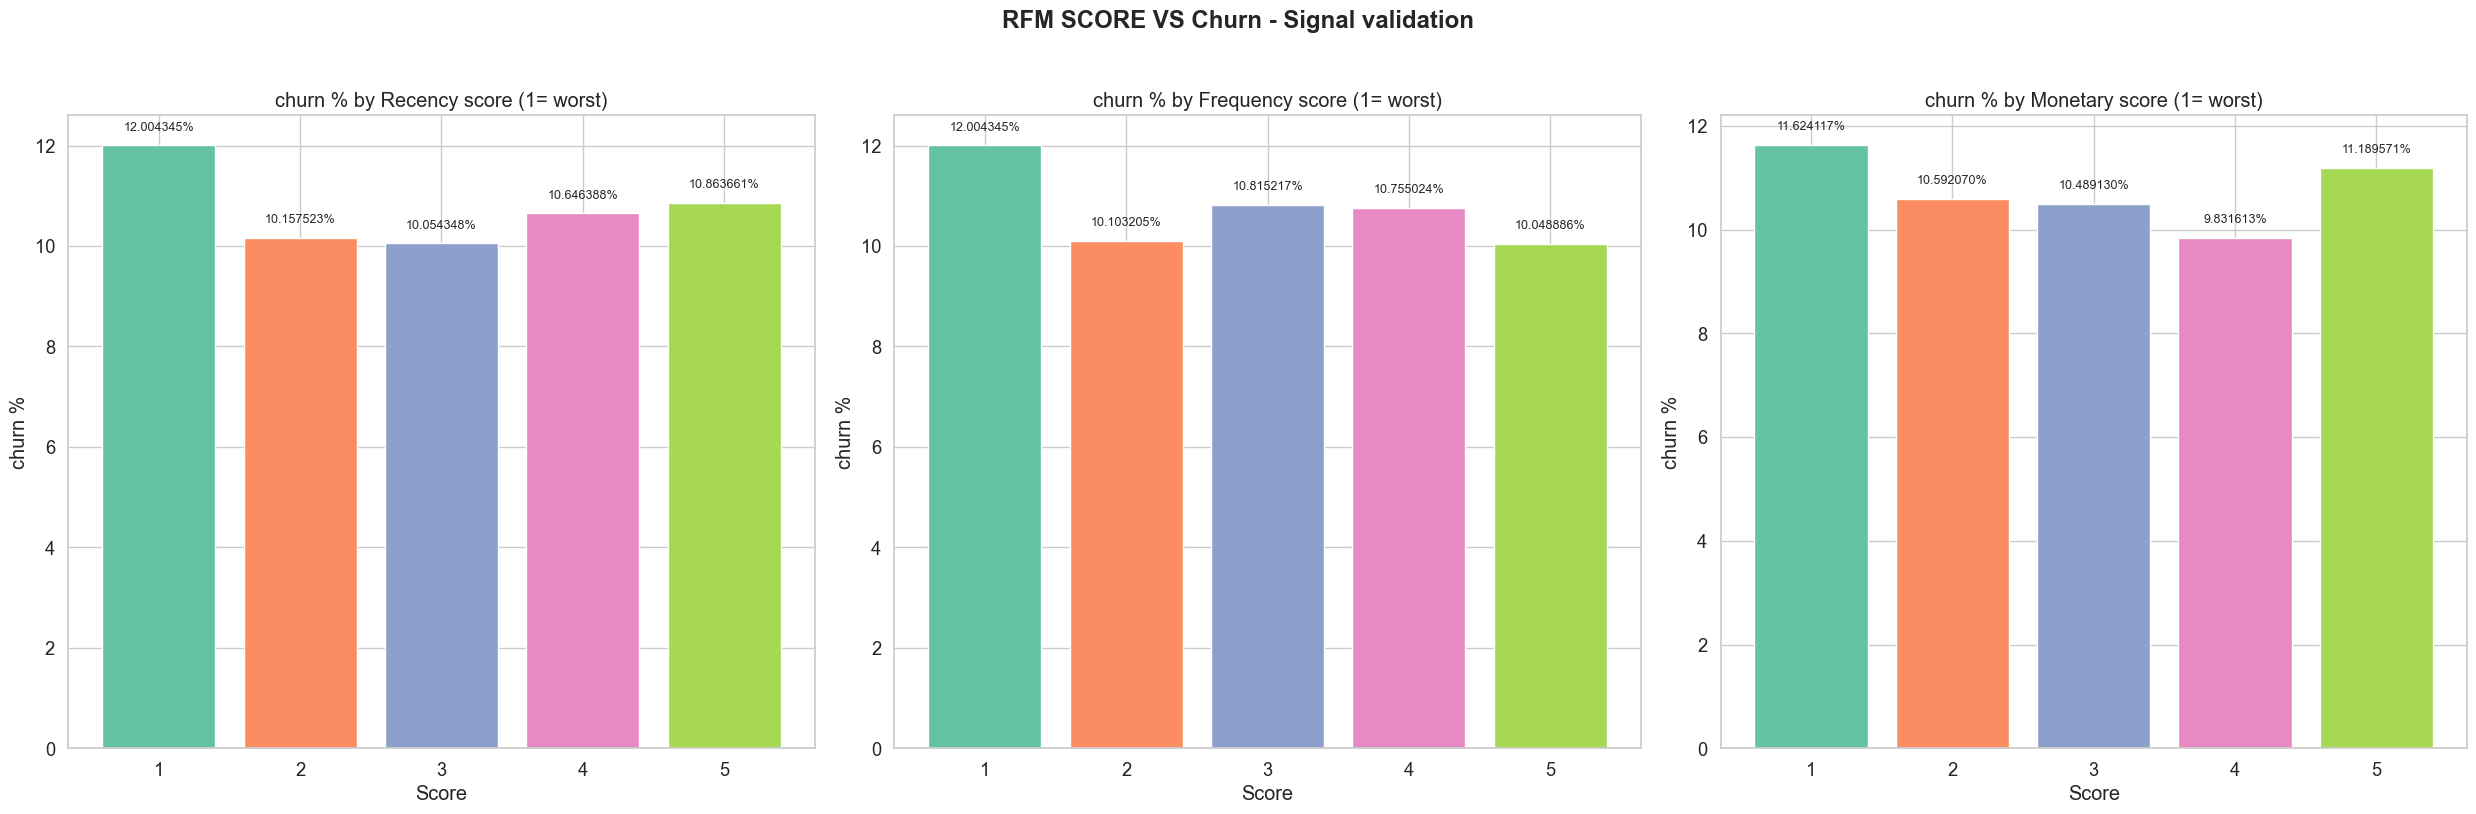

In [35]:
rfm_churn = rfm.merge(eligible, on="user_id", how="left")
fig, axes = plt.subplots(1,3, figsize = (25,8))
for ax, col, title in zip(
    axes,
    ["recency_score", "frequency_score","monetary_score"],
    ["Recency","Frequency","Monetary"]

):
    data = rfm_churn.groupby(col)["churned"].mean().mul(100).reset_index()
    ax.bar(
        data[col].astype(str), data["churned"],
        color =sns.color_palette("Set2"), edgecolor="white"
    )
    ax.set(
        title=f"churn % by {title} score (1= worst)",
        xlabel = "Score", ylabel = "churn %"
    )
    for _, row in data.iterrows():
        ax.text(row[col] - 1, row["churned"] + 0.3, f"{row["churned"]:1f}%",ha="center",fontsize =9)
plt.suptitle("RFM SCORE VS Churn - Signal validation", fontweight ="bold", y=1.02)
plt.tight_layout()
plt.show()

## Step 3  Behavioural Features

- Captured how users engage, not just how much , when last or how often
- E.G two riders with 10 trips per month might have totally churn risk
- one of these 2 riders only commutes during rush hour VS randomly on a weekend
- The poattern matters as much

In [36]:
# Trips pattern Features

# Step 3a Peak Hours
PEAK_HOURS = list(range(7,10)) + list(range(17,20))
PAYMENT_MAP ={"Card" : 0, "Cash" : 1, "Wallet" : 2, "Corporate" : 3}


# 1 - define if a trip was during peak hour 
# 2 - define if a trip was during the weekend 
# 3 - define if a trip was on a rainy day


trips["is_peak"]  = trips["hour_of_day"].isin(PEAK_HOURS).astype(int)
trips["is_weekend"] = trips["day_of_week"].isin(["Saturday","Sunday"]).astype(int)
trips["is_rainy"]  = (trips["weather"] == "Rainy"). astype(int)



# Aggregate our trips dataset to derive more features
behavioral = (
    trips.groupby("user_id")
    .agg(

        #aggregated features
        avg_trip_duration = ("trip_duration", "mean"),
        avg_fare = ("fare", "mean"),
        avg_surge = ("surge_multiplier", "mean"),
        tip_rate = ("tip", lambda x:(x > 0).mean()),

        # Earlier engineered features
        peak_hour_rate = ("is_peak", "mean"),
        weekend_ratio = ("is_weekend", "mean"),
        rainy_ride_ratio = ("is_rainy", "mean")
    ).round(2).reset_index()
)

In [37]:
behavioral.head()

,user_id,avg_trip_duration,avg_fare,avg_surge,tip_rate,peak_hour_rate,weekend_ratio,rainy_ride_ratio
0,R00000,30.32,14.64,1.10,0.40,0.20,0.16,0.16
1,R00001,28.64,12.90,1.07,0.21,0.21,0.29,0.00
2,R00002,31.54,15.79,1.19,0.21,0.38,0.12,0.25
3,R00003,32.56,13.50,1.16,0.22,0.11,0.33,0.33
4,R00004,36.12,16.78,1.26,0.44,0.25,0.44,0.25


In [38]:
## Step 3b

# Preferred Payment  Driver Engineering
# preferred payment (most frequent )it tells us the stickness level
#it tells us the stickness level


# Preferred Payment (most frequent)
payment_mode = (
    trips.groupby("user_id")["payment_type"]
    .agg(lambda x: x.mode().iloc[0]).reset_index() )



# attach these payment method to payment method to payment map (encoded)
payment_mode["preferred_payment_encoded"] = (
    payment_mode["payment_type"].map(PAYMENT_MAP).fillna(0).astype(int))


# merge all of these new info Behavioral
behavioral = behavioral.merge(
    payment_mode[["user_id", "preferred_payment_encoded"]], on="user_id", how="left"
)


In [39]:
## Step 3c

## Drivers' Quality
# for example is the avergae rating for driver is 4.5, driver that surpass

trips_rated  = trips.merge(
    drivers[["driver_id", "rating"]], on ="driver_id", how = "left"
)

driver_quality= (
    trips_rated.groupby("user_id")["rating"].mean()
    .reset_index(name ="avg_driver_rating_received").round(3)
)


# sep 3c(iii) - We merge driver's quality into the behavioral dataframe
behavioral = behavioral.merge(driver_quality, on ="user_id", how ="left")

## Step 3c(iv) We engineer a new column aveerage drivers rating received 
behavioral["avg_driver_received"]= (
    behavioral["avg_driver_rating_received"].fillna(behavioral["avg_driver_rating_received"].median())

)

## Step 3d - Session / Engagement Feature

In [40]:
# session Frequency Windows 

sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 16:52:06,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 05:05:22,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 21:12:25,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:26:25,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:17:22,4,1,0,Lagos,Bronze


In [45]:
#  Convert session_time to datetime
sessions["session_time"] = pd.to_datetime(sessions["session_time"])

# session frequency window
sess_freq = pd.DataFrame({"user_id":sessions["rider_id"].unique()})


# loops to iterate over the sessions
for days in [30, 60]:
    cutoff = reference_date - pd.Timedelta(days = days)

    counts = (

        # Cutoff for 30days 
        sessions[ sessions["session_time"] >= cutoff]
        .groupby("rider_id").size()
        .reset_index(name=f"sessions_last_{days}d")
        .rename(columns = {"rider_id": "user_id"})

    )
    sess_freq = sess_freq.merge(counts, on= "user_id", how = "left")

# cleaning of the new columns
sess_freq[["sessions_last_30d", "sessions_last_60d"]] = (
    sess_freq[["sessions_last_30d", "sessions_last_60d"]].fillna(0).astype(int)

)


# Engagement  Depth
engagement = (
    sessions.groupby("rider_id")
    .agg(
        avg_time_on_app = ("time_on_app" , "mean"),
        avg_pages_visited = ("pages_visited", "mean"),
        session_conversion_rate = ("converted", "mean"),
    )
    .round(2).reset_index()
    .rename(columns = {"rider_id" : "user_id"})
)

# Engagement Score 
engagement["engagement_score"] = (
    engagement["avg_time_on_app"] *  engagement["avg_pages_visited"]
).round(2)


session_features = sess_freq.merge(engagement, on="user_id", how="left")

fill_cols = ["avg_time_on_app", "avg_pages_visited", "session_conversion_rate", "engagement_score"]
session_features[fill_cols] = session_features[fill_cols].fillna(0)

print (f"session features: {session_features.shape}")
print (session_features.describe().round(2))

session features: (9929, 7)
       sessions_last_30d  sessions_last_60d  avg_time_on_app  \
count            9929.00            9929.00          9929.00   
mean                5.04               5.04            98.15   
std                 2.20               2.20           108.27   
min                 1.00               1.00             0.00   
25%                 3.00               3.00            37.50   
50%                 5.00               5.00            65.45   
75%                 6.00               6.00           115.00   
max                16.00              16.00          1800.00   

       avg_pages_visited  session_conversion_rate  engagement_score  
count            9929.00                  9929.00           9929.00  
mean                2.77                     0.16            270.34  
std                 0.79                     0.20            319.42  
min                 1.00                     0.00              0.00  
25%                 2.25                     

## Step 4 Temporal Features

In [43]:
set(fill_cols) - set(session_features.columns)

{'avg_pages_visited',
 'avg_time_on_app',
 'engagement_score',
 'session_conversion_rate'}

In [ ]:
# Activity Trend

# Filter eligible users
temporal = riders[
    riders["user_id"].isin(eligible["user_id"])
][["user_id", "account_age_days"]].copy()

# Cutoffs
cutoff_30 = reference_date - pd.Timedelta(days=30)
cutoff_60 = reference_date - pd.Timedelta(days=60)

# Recent activity (last 30 days)
recent = (
    trips[trips["pickup_time"] >= cutoff_30]
    .groupby("user_id")
    .size()
    .reset_index(name="r30")
)

# Prior activity (30–60 days ago)
prior = (
    trips[
        (trips["pickup_time"] >= cutoff_60) &
        (trips["pickup_time"] < cutoff_30)
    ]
    .groupby("user_id")
    .size()
    .reset_index(name="p30")
)

# Merge
temporal = (
    temporal
    .merge(recent, on="user_id", how="left")
    .merge(prior, on="user_id", how="left")
)

# Fill missing
temporal[["r30", "p30"]] = temporal[["r30", "p30"]].fillna(0)

# ✅ Proper Activity Trend
temporal["activity_trend"] = (temporal["r30"] - temporal["p30"]).round(2)

# Optional (better metric)
temporal["activity_ratio"] = (
    temporal["r30"] / temporal["p30"].replace(0, 1)
).round(2)

# Unique active days
trips["pickup_date"] = trips["pickup_time"].dt.date

unique_days = (
    trips.groupby("user_id")["pickup_date"]
    .nunique()
    .reset_index(name="unique_active_days")
)

# Merge
temporal = temporal.merge(unique_days, on="user_id", how="left")

# Fill missing
temporal["unique_active_days"] = temporal["unique_active_days"].fillna(0).astype(int)

In [ ]:
print (f"temporal features: {temporal.shape}")
print (temporal.describe().round(2))

temporal features: (9204, 7)
       account_age_days      r30      p30  activity_trend  activity_ratio  \
count           9204.00  9204.00  9204.00          9204.0         9204.00   
mean             393.90     1.64     1.64             0.0            1.16   
std              194.87     1.28     1.28             1.8            1.11   
min               60.00     0.00     0.00            -7.0            0.00   
25%              225.00     1.00     1.00            -1.0            0.33   
50%              395.00     1.00     1.00             0.0            1.00   
75%              563.00     2.00     2.00             1.0            2.00   
max              731.00     8.00     9.00             7.0            8.00   

       unique_active_days  
count             9204.00  
mean                19.46  
std                  4.30  
min                  6.00  
25%                 16.00  
50%                 19.00  
75%                 22.00  
max                 40.00  


## Step 5 Merge,  Analyse, Save 

In [52]:
LOYALTY_MAP = {"Bronze" : 0, "Silver" : 1, "Gold": 2, "Platinum" : 3}
CITY_MAP = {"Nairobi" : 0, "Lagos" : 1 , "Cairo" : 2}

riders_cats = riders [riders["user_id"].isin(eligible ["user_id"])][
    ["user_id", "loyalty_status", "city", "was_referred", "avg_rating_given"]
].copy()
riders_cats["loyalty_encoded"] = riders_cats["loyalty_status"].map(LOYALTY_MAP)
riders_cats["city_encoded"] = riders_cats["city"].map(CITY_MAP)
riders_cats = riders_cats.drop(columns=["loyalty_status", "city"])

# Merge all feature groups (eligible riders only)
features = (
    eligible 
    .merge (recency, on = "user_id", how = "left")
    .merge (frequency, on = "user_id", how = "left")
    .merge (monetary, on = "user_id", how = "left")
    .merge (rfm, on = "user_id", how = "left") 
    .merge (behavioral, on = "user_id", how = "left")
    .merge (session_features, on = "user_id", how = "left")
    .merge (temporal, on = "user_id", how = "left")
    .merge (riders_cats, on = "user_id", how = "left")
)

features[fill_cols] = features[fill_cols].fillna(0)
features = features.fillna(0)

print (f"Feature matrix : {features.shape[0]:,} riders, {features.shape[1]:,} columns")
print (f"Null count    : {features.isnull().sum().sum()}")

Feature matrix : 9,204 riders, 45 columns
Null count    : 0


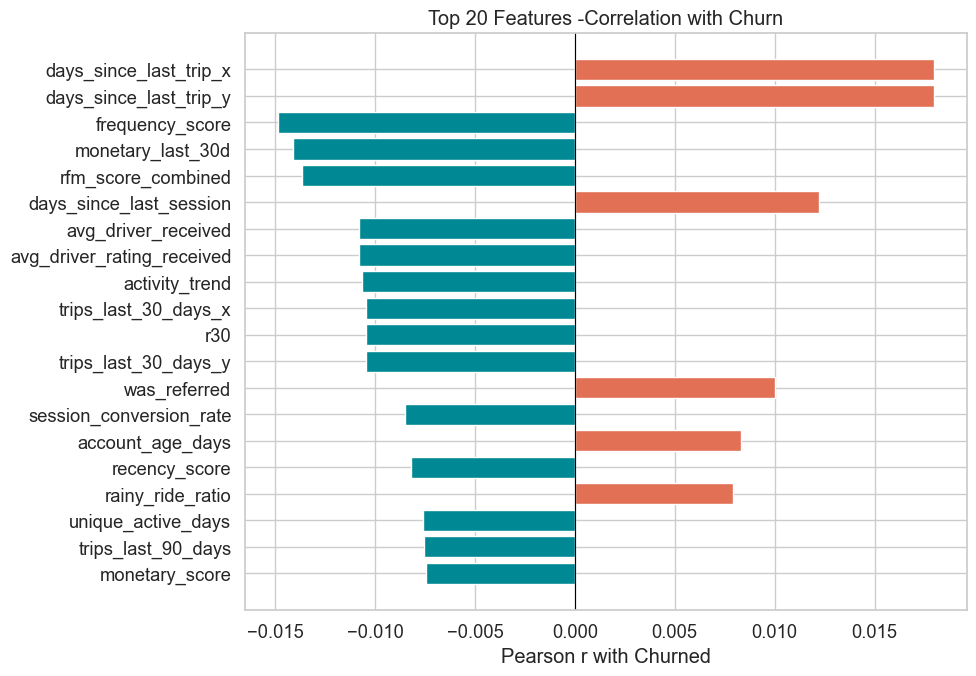


Top 10:
days_since_last_trip_x        0.018
days_since_last_trip_y        0.018
frequency_score              -0.015
monetary_last_30d            -0.014
rfm_score_combined           -0.014
days_since_last_session       0.012
avg_driver_received          -0.011
avg_driver_rating_received   -0.011
activity_trend               -0.011
trips_last_30_days_x         -0.010


In [54]:
feature_columns = [c for c in features.columns if c not in ["user_id", "churned"]]
corr = features[feature_columns + ["churned"]].corr()["churned"].drop("churned").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20 = corr.head(20)
colors = [ "#E17055" if v > 0 else "#008894" for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Top 20 Features -Correlation with Churn", xlabel="Pearson r with Churned")
plt.tight_layout()
plt.show()

print ("\nTop 10:")
print (corr.head(10).round(3).to_string())

In [60]:
import os
os.getcwd()

'c:\\Users\\colge\\OneDrive\\Downloads\\Ridewise_London-Gbolahan\\notebooks'

In [62]:
out_path = "features.csv"
features.to_csv(out_path, index=False)

In [64]:
import os

# Define folder
DATA_PROCESSED = "data/processed"

# Create folder if it doesn't exist
os.makedirs(DATA_PROCESSED, exist_ok=True)

# Save file
out_path = os.path.join(DATA_PROCESSED, "features.csv")
features.to_csv(out_path, index=False)

# Print info
print(f"Saved feature.csv ({features.shape[0]:,} rows x {features.shape[1]} columns)")
print(f"Path: {os.path.abspath(out_path)}")

print("\nAll columns:")
for i, col in enumerate(features.columns, 1):
    print(f"{i:>2}. {col}")

Saved feature.csv (9,204 rows x 45 columns)
Path: c:\Users\colge\OneDrive\Downloads\Ridewise_London-Gbolahan\notebooks\data\processed\features.csv

All columns:
 1. user_id
 2. churned
 3. days_since_last_trip_x
 4. days_since_last_session
 5. trips_last_7_days
 6. trips_last_30_days_x
 7. trips_last_60_days
 8. trips_last_90_days
 9. monetary_total_x
10. monetary_avg
11. trips_lifetime
12. monetary_last_30d
13. days_since_last_trip_y
14. trips_last_30_days_y
15. monetary_total_y
16. recency_score
17. frequency_score
18. monetary_score
19. rfm_score_combined
20. avg_trip_duration
21. avg_fare
22. avg_surge
23. tip_rate
24. peak_hour_rate
25. weekend_ratio
26. rainy_ride_ratio
27. preferred_payment_encoded
28. avg_driver_rating_received
29. avg_driver_received
30. sessions_last_30d
31. sessions_last_60d
32. avg_time_on_app
33. avg_pages_visited
34. session_conversion_rate
35. engagement_score
36. account_age_days
37. r30
38. p30
39. activity_trend
40. activity_ratio
41. unique_active_da